#### 1. Цель EDA

В этом EDA используется EdTech-датасет OULAD (анонимизированный набор данных Open University Learning Analytics Dataset), содержащий данные о модулях, презентациях, оценочных мероприятиях, учебных материалах, регистрации студентов, результатах оценивания и активности в VLE (Virtual Learning Environment).

Подробное описание датасета и всех таблиц вынесено в отдельный файл: [описание датасета](../dataset_description.md)

ERD-диаграмма представлена [здесь](../pics/ERD_oulad.png)

Основная цель EDA — понять структуру EdTech-датасета, проверить качество данных, определить роль каждой таблицы в будущей аналитической модели и подготовить основу для дальнейшего SQL-анализа и визуализации.

#### 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
studinfo = pd.read_csv('../raw_data/studentInfo.csv')
studreg = pd.read_csv('../raw_data/studentRegistration.csv')
studvle = pd.read_csv('../raw_data/studentVle.csv')
courses = pd.read_csv('../raw_data/courses.csv')
studass = pd.read_csv('../raw_data/studentAssessment.csv')
assess = pd.read_csv('../raw_data/assessments.csv')
vle = pd.read_csv('../raw_data/vle.csv')


In [12]:
print(f'studentInfo: {studinfo.shape}')
print(f'studentRgistration: {studreg.shape}')
print(f'studentVle: {studvle.shape}')
print(f'courses: {courses.shape}')
print(f'studentAssessment: {studass.shape}')
print(f'assessments: {assess.shape}')
print(f'vle: {vle.shape}')

studentInfo: (32593, 12)
studentRgistration: (32593, 5)
studentVle: (10655280, 6)
courses: (22, 3)
studentAssessment: (173912, 5)
assessments: (206, 6)
vle: (6364, 6)


## studentInfo

In [25]:
studinfo.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [49]:
studinfo.sample(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
2658,BBB,2013J,260179,F,Scotland,Lower Than A Level,30-40%,0-35,1,60,N,Pass
20814,EEE,2014B,620215,M,North Western Region,A Level or Equivalent,0-10%,0-35,0,60,Y,Pass
2808,BBB,2013J,379983,F,Wales,A Level or Equivalent,0-10%,0-35,1,60,N,Fail
5042,BBB,2014B,470113,F,London Region,A Level or Equivalent,0-10%,0-35,0,60,N,Pass
1722,BBB,2013B,539365,F,London Region,Lower Than A Level,20-30%,35-55,0,60,N,Pass
5120,BBB,2014B,513077,F,Wales,Lower Than A Level,20-30%,35-55,0,120,Y,Fail
23008,FFF,2013B,524609,M,West Midlands Region,Lower Than A Level,10-20,35-55,1,120,N,Withdrawn
8527,BBB,2014J,2051809,M,London Region,HE Qualification,10-20,35-55,0,120,N,Withdrawn
15467,DDD,2013J,574938,M,West Midlands Region,A Level or Equivalent,0-10%,0-35,0,60,N,Distinction
25583,FFF,2013J,598215,M,South Region,A Level or Equivalent,50-60%,0-35,0,60,N,Pass


In [54]:
studinfo.nunique()

code_module                 7
code_presentation           4
id_student              28785
gender                      2
region                     13
highest_education           5
imd_band                   10
age_band                    3
num_of_prev_attempts        7
studied_credits            61
disability                  2
final_result                4
dtype: int64

In [ ]:
studinfo.duplicated(subset=['code_module', 'code_presentation', 'id_student']).sum()

np.int64(0)

In [72]:
studinfo['gender'].value_counts(dropna=False)

gender
M    17875
F    14718
Name: count, dtype: int64

In [73]:
studinfo['gender'].value_counts(normalize=True, dropna=False)

gender
M    0.548431
F    0.451569
Name: proportion, dtype: float64

In [ ]:
studinfo['region'].value_counts(dropna=False)

region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64

In [67]:
studinfo['region'].value_counts(normalize=True, dropna=False)

region
Scotland                0.105728
East Anglian Region     0.102476
London Region           0.098671
South Region            0.094867
North Western Region    0.089160
West Midlands Region    0.079219
South West Region       0.074740
East Midlands Region    0.072562
South East Region       0.064769
Wales                   0.064001
Yorkshire Region        0.061547
North Region            0.055932
Ireland                 0.036327
Name: proportion, dtype: float64

In [74]:
studinfo['highest_education'].value_counts(dropna=False)

highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

In [75]:
studinfo['highest_education'].value_counts(normalize=True, dropna=False)

highest_education
A Level or Equivalent          0.430921
Lower Than A Level             0.403706
HE Qualification               0.145123
No Formal quals                0.010646
Post Graduate Qualification    0.009603
Name: proportion, dtype: float64

|Уровень образования|Интерпретация|
|---|---|
|No Formal quals|Отсутствие формального образования|
|Lower Than A Level|Средняя школа|
|A Level or Equivalent|Старшая школа|
|HE Qualification|Бакалавриат / специалитет|
|Post Graduate Qualification|Магиструтура и выше|

In [76]:
studinfo['imd_band'].value_counts(dropna=False)

imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64

In [78]:
studinfo['imd_band_clean'] = studinfo['imd_band'].replace({'10-20': '10-20%'})

In [80]:
studinfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_band_clean
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,90-100%
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,20-30%
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,30-40%
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,50-60%
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,50-60%


In [81]:
studinfo['imd_band_clean'].value_counts(dropna=False)

imd_band_clean
20-30%     3654
30-40%     3539
10-20%     3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64

В столбце imd_band выявлено значение 10-20, тогда как остальные интервалы заданы в процентном формате. По структуре признака и общей логике шкалы значение было интерпретировано как 10-20% и приведено к единому формату в отдельном очищенном поле imd_band_clean.

In [77]:
studinfo['imd_band'].value_counts(normalize=True, dropna=False)

imd_band
20-30%     0.112110
30-40%     0.108582
10-20      0.107876
0-10%      0.101586
40-50%     0.099899
50-60%     0.095849
60-70%     0.089130
70-80%     0.088332
80-90%     0.084742
90-100%    0.077808
NaN        0.034087
Name: proportion, dtype: float64

In [88]:
studinfo['imd_band_missing'] = studinfo['imd_band'].isna()

In [91]:
region_missing = (
    pd.crosstab(studinfo['region'], studinfo['imd_band_missing'], normalize='index') * 100
).rename(columns={False: 'not_missing_pct', True: 'missing_pct'}).sort_values('missing_pct', ascending=False)

region_missing

imd_band_missing,not_missing_pct,missing_pct
region,,
North Region,59.901262,40.098738
Ireland,77.533784,22.466216
South Region,98.447607,1.552393
West Midlands Region,98.489543,1.510457
Scotland,99.651770,0.348230
Yorkshire Region,99.750748,0.249252
South West Region,99.794745,0.205255
North Western Region,99.827942,0.172058
East Anglian Region,100.000000,0.000000


<Axes: ylabel='region'>

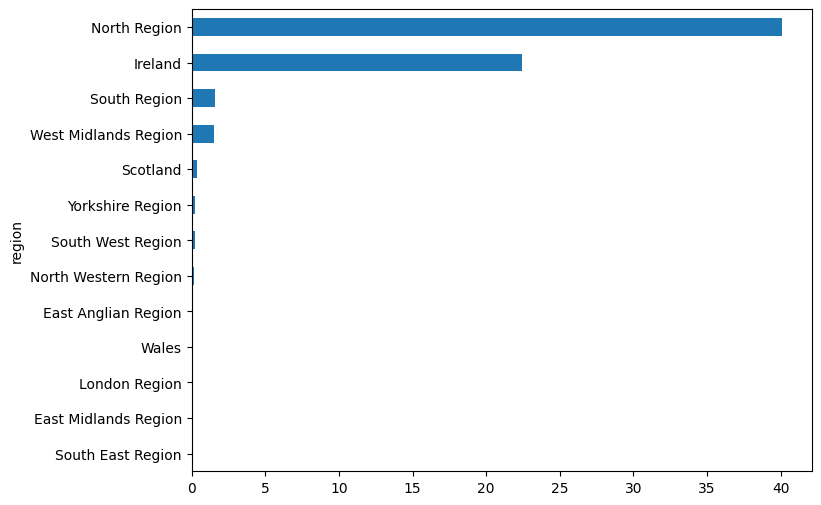

In [93]:
region_missing.sort_values('missing_pct', ascending=True)['missing_pct'].plot(kind='barh', figsize=(8,6))

Пропуски в imd_band распределены неравномерно по регионам. Наибольшая доля пропусков наблюдается в North Region (40.1%) и Ireland (22.5%), тогда как в ряде регионов пропуски отсутствуют полностью. Это указывает на систематический характер пропусков и позволяет предположить, что отсутствие imd_band связано с региональными особенностями формирования или сопоставления данных, а не со случайной потерей значений.

In [95]:
studinfo.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'imd_band_clean',
       'imd_band_missing'],
      dtype='str')

In [96]:
studinfo = studinfo[['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'imd_band_clean', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'imd_band_missing']]

In [ ]:
studinfo['age_band'].value_counts(dropna=False)

In [ ]:
studinfo['age_band'].value_counts(normalize=True, dropna=False)

## studentRegistration

In [26]:
studreg.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB


In [37]:
studreg.sample(10)

,code_module,code_presentation,id_student,date_registration,date_unregistration
12292,CCC,2014J,649413,-150.0,-148.0
26865,FFF,2014B,606977,-146.0,NaN
6977,BBB,2014J,592139,-120.0,NaN
19298,DDD,2014J,2471812,-38.0,10.0
12827,CCC,2014J,699370,-9.0,NaN
4107,BBB,2013J,596820,-79.0,NaN
24369,FFF,2013J,470461,-38.0,NaN
14395,DDD,2013J,8462,-137.0,119.0
19194,DDD,2014J,1684787,-127.0,NaN
25180,FFF,2013J,584446,-138.0,NaN


## studentVle

In [27]:
studvle.info()

<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 487.8 MB


In [36]:
studvle.sample(10)

,code_module,code_presentation,id_student,id_site,date,sum_click
960401,BBB,2013J,593514,703895,83,11
4049639,DDD,2013J,561881,673519,109,3
6524042,FFF,2013B,551142,527358,30,4
10256569,FFF,2014J,647425,882670,242,2
5807578,EEE,2014B,2600862,790866,149,14
1940292,CCC,2014B,583906,730016,-3,2
6682957,FFF,2013B,395588,526827,67,22
2230838,CCC,2014B,626614,729788,123,6
4025871,DDD,2013J,513853,674119,96,1
3158705,DDD,2013B,423876,547918,-4,1


## courses

In [28]:
courses.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 660.0 bytes


In [38]:
courses.sample(10)

,code_module,code_presentation,module_presentation_length
1,AAA,2014J,269
15,FFF,2013J,268
14,EEE,2014B,241
11,DDD,2014B,241
3,BBB,2014J,262
8,DDD,2013J,261
17,FFF,2013B,240
21,GGG,2014B,241
20,GGG,2014J,269
10,DDD,2013B,240


## studentAssessment

In [29]:
studass.info()

<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


In [39]:
studass.sample(10)

,id_assessment,id_student,date_submitted,is_banked,score
81878,25353,426059,204,0,60.0
70178,25340,2088765,230,0,60.0
118012,34874,173412,47,0,76.0
140798,34895,2666831,168,0,71.0
6218,14986,533347,83,0,61.0
82267,25353,588293,207,0,78.0
168949,37432,624569,207,0,100.0
115409,34871,313975,199,0,94.0
134772,34888,402806,101,0,36.0
79470,25350,606344,85,0,95.0


## assessments

In [30]:
assess.info()

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.8 KB


In [40]:
assess.sample(10)

,code_module,code_presentation,id_assessment,assessment_type,date,weight
89,DDD,2013J,25349,TMA,53.0,12.5
91,DDD,2013J,25351,TMA,123.0,20.0
83,DDD,2013B,25336,TMA,81.0,12.5
78,DDD,2013B,25345,CMA,149.0,4.0
162,FFF,2014B,34898,Exam,227.0,100.0
16,BBB,2013B,14995,CMA,187.0,1.0
181,GGG,2013J,37423,CMA,229.0,0.0
202,GGG,2014J,37435,TMA,61.0,0.0
128,FFF,2013B,34869,CMA,222.0,0.0
23,BBB,2013B,14990,Exam,NaN,100.0


## vle

In [31]:
vle.info()

<class 'pandas.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   str    
 2   code_presentation  6364 non-null   str    
 3   activity_type      6364 non-null   str    
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 298.4 KB


In [41]:
vle.sample(10)

,id_site,code_module,code_presentation,activity_type,week_from,week_to
4020,832566,EEE,2014J,forumng,NaN,NaN
2926,773054,DDD,2014B,subpage,NaN,NaN
3946,832672,EEE,2014J,oucontent,13.0,13.0
5123,779424,FFF,2014B,oucontent,29.0,29.0
1262,768514,BBB,2014B,resource,NaN,NaN
5836,883232,FFF,2014J,url,23.0,23.0
553,543160,BBB,2013B,resource,NaN,NaN
847,703731,BBB,2013J,forumng,NaN,NaN
3081,773388,DDD,2014B,resource,NaN,NaN
1442,913519,BBB,2014J,oucontent,6.0,6.0
